Loading Cleaned Data for EDA...
 Data Loaded. Total rows: 4926


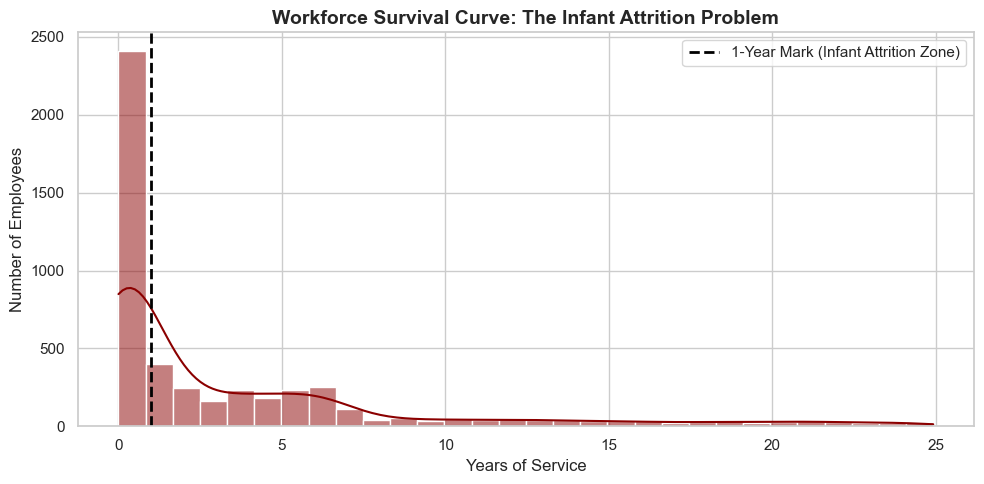

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for professional presentation charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Loading Cleaned Data for EDA...")
df = pd.read_csv("../data/processed/Hela_ML_Ready.csv")
print(f" Data Loaded. Total rows: {len(df)}")

# CHART 1: THE "INFANT ATTRITION" CRISIS
# Shows the massive drop-off in the first year
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Service_Years_Numeric', bins=30, kde=True, color='darkred')
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='1-Year Mark (Infant Attrition Zone)')
plt.title("Workforce Survival Curve: The Infant Attrition Problem", fontsize=14, fontweight='bold')
plt.xlabel("Years of Service", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

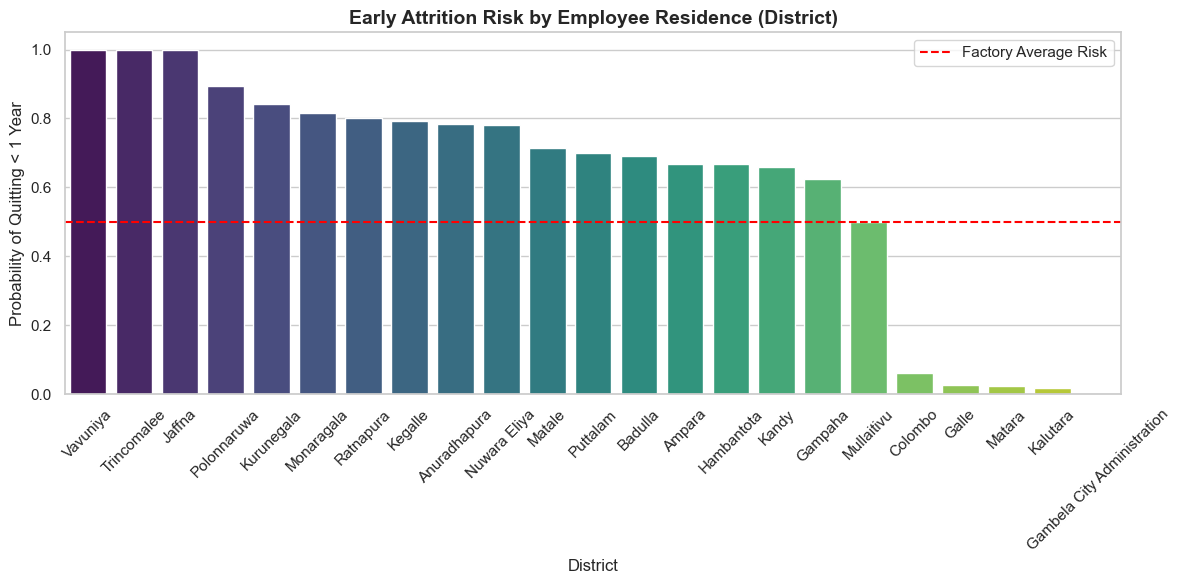

In [3]:
# CHART 2: ATTRITION BY DISTRICT (The Distance Factor)
# Which regions have the highest failure rates?
plt.figure(figsize=(12, 6))
# Calculate attrition rate per district
district_risk = df.groupby('District')['Early_Attrition'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=district_risk, x='District', y='Early_Attrition', hue='District', legend=False, palette='viridis')
plt.title("Early Attrition Risk by Employee Residence (District)", fontsize=14, fontweight='bold')
plt.xlabel("District", fontsize=12)
plt.ylabel("Probability of Quitting < 1 Year", fontsize=12)
plt.axhline(y=df['Early_Attrition'].mean(), color='red', linestyle='--', label='Factory Average Risk')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

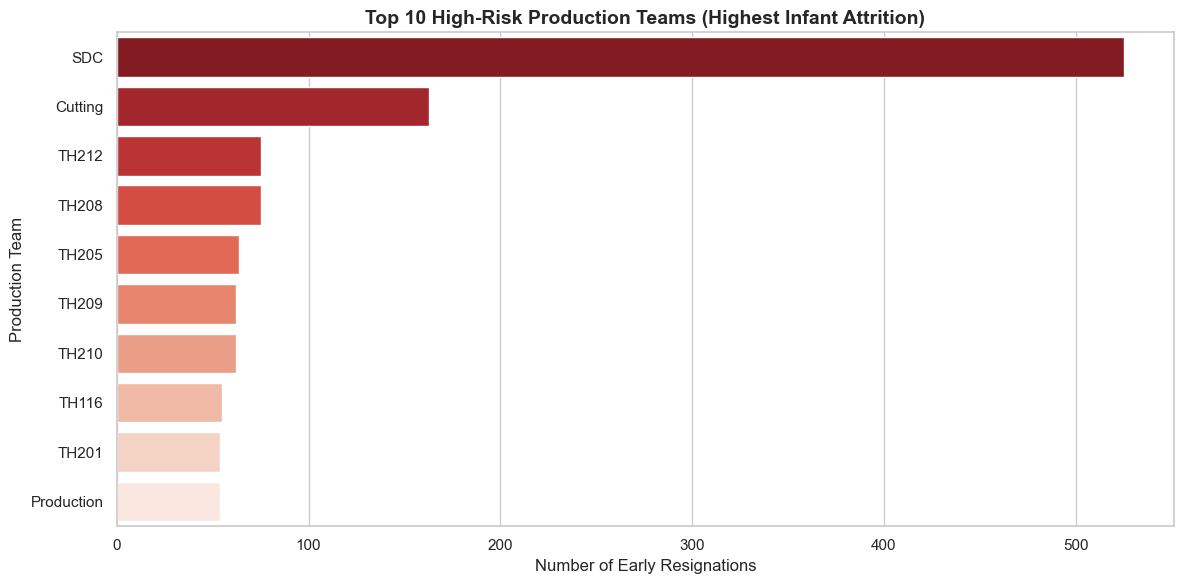

In [4]:
# CHART 3: TEAM VULNERABILITY (Where is the bleeding?)
# Top 10 Teams with the highest count of early resignations
plt.figure(figsize=(12, 6))
# Filter only the early leavers, count by team, get top 10
top_teams = df[df['Early_Attrition'] == 1]['Team'].value_counts().head(10).reset_index()
top_teams.columns = ['Team', 'Leavers_Count']

sns.barplot(data=top_teams, y='Team', x='Leavers_Count', hue='Team', legend=False, palette='Reds_r')
plt.title("Top 10 High-Risk Production Teams (Highest Infant Attrition)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Early Resignations", fontsize=12)
plt.ylabel("Production Team", fontsize=12)
plt.tight_layout()
plt.show()

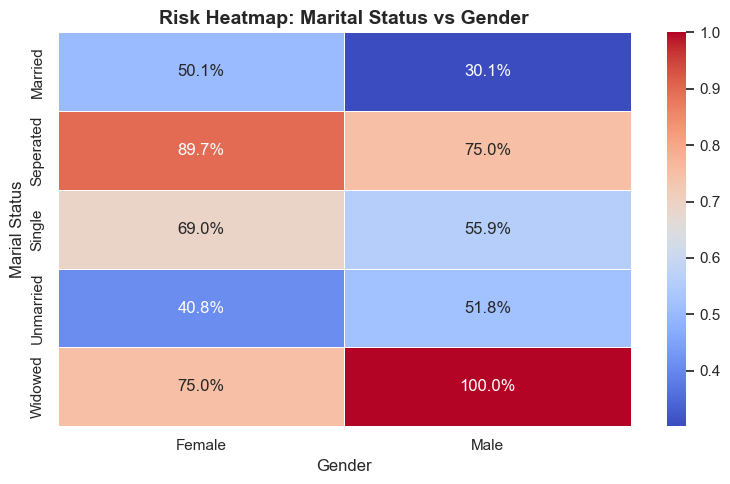

In [5]:
# CHART 4: DEMOGRAPHIC HEATMAP (Marital Status vs Gender)
plt.figure(figsize=(8, 5))
heatmap_data = pd.pivot_table(df, values='Early_Attrition', index='Marial Status', columns='Gender', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".1%", linewidths=.5)
plt.title("Risk Heatmap: Marital Status vs Gender", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()